<a href="https://colab.research.google.com/github/dhritiburugupalli/cloud-seeding-project/blob/main/phase2final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving data - Sheet5.csv to data - Sheet5.csv


In [1]:
# installations
!pip install pandas numpy scikit-learn matplotlib seaborn
import pandas
import numpy
import sklearn
import matplotlib
import seaborn
import seaborn as sns

In [6]:
df = pd.read_csv("data - Sheet5.csv")  # replace with your filename
print(df.head())

  storm_event_id storm_start   storm_end  duration_hours_reported  swe_change  \
0      storm_004  2020-01-01  2020-01-02                   355.50         1.9   
1      storm_026  2021-02-15  2021-02-17                   378.00         2.8   
2      storm_038  2022-03-08  2022-03-09                   410.00         1.3   
3      storm_006  2020-01-12  2020-01-13                   127.75         2.7   
4      storm_022  2021-01-29  2021-01-30                   174.25         1.0   

   precip_total  temp_avg  temp_min freezing peak_dbz_bin intensity_category  \
0           1.5     21.20      18.3      yes        20-30           moderate   
1           2.6     18.83       7.0      yes        30-40              heavy   
2           1.3     17.15       2.3      yes        30-40              heavy   
3           1.3     16.40      12.7      yes        20-30           moderate   
4           0.8     24.25      16.0      yes        20-30           moderate   

  organized cloud_top_category c

In [7]:
# SWE efficiency
df["swe_efficiency"] = df["swe_change"] / df["precip_total"]

# Temperature spread
df["temp_spread"] = df["temp_avg"] - df["temp_min"]

# Encode categorical variables
dbz_map = {"10-20": 1, "20-30": 2, "30-40": 3}
cloud_top_map = {"warm": 1, "moderately_cold": 2, "very_cold": 3}
cloud_extent_map = {"limited": 1, "partial": 2, "widespread": 3}
binary_map = {"no": 0, "yes": 1}

df["dbz_score"] = df["peak_dbz_bin"].map(dbz_map)
df["cloud_top_score"] = df["cloud_top_category"].map(cloud_top_map)
df["cloud_extent_score"] = df["cloud_extent"].map(cloud_extent_map)
df["organized_score"] = df["organized"].map(binary_map)
df["deep_cloud_score"] = df["deep_cloud_present"].map(binary_map)

In [8]:
def compute_score(row):
    score = 0

    if row["organized_score"] == 1:
        score += 2
    if row["deep_cloud_score"] == 1:
        score += 2
    if row["cloud_top_score"] == 2:
        score += 1
    if row["cloud_top_score"] == 3:
        score += 2
    if row["cloud_extent_score"] == 2:
        score += 1
    if row["cloud_extent_score"] == 3:
        score += 2
    if row["dbz_score"] == 2:
        score += 1
    if row["dbz_score"] == 3:
        score += 2
    if 15 <= row["temp_avg"] <= 24:
        score += 2
    if row["precip_total"] > df["precip_total"].median():
        score += 1

    return score

df["pattern_score"] = df.apply(compute_score, axis=1)

In [9]:
def classify(score):
    if score <= 4:
        return 0  # low pattern
    elif score <= 7:
        return 1  # moderate pattern
    else:
        return 2  # high pattern

df["pattern_class"] = df["pattern_score"].apply(classify)

In [10]:
features = [
    "duration_hours_reported",
    "precip_total",
    "temp_avg",
    "temp_min",
    "swe_efficiency",
    "dbz_score",
    "cloud_top_score",
    "cloud_extent_score",
    "organized_score",
    "deep_cloud_score"
]

X = df[features]
y = df["pattern_class"]

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_model = LogisticRegression(max_iter=1000)
log_acc = cross_val_score(log_model, X, y, cv=5).mean()

print("Logistic Regression Accuracy:", log_acc)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Logistic Regression Accuracy: 0.6733333333333332


In [12]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3)
tree_acc = cross_val_score(tree, X, y, cv=5).mean()

print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.7533333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf_acc = cross_val_score(rf, X, y, cv=5).mean()

print("Random Forest Accuracy:", rf_acc)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Random Forest Accuracy: 0.7866666666666666


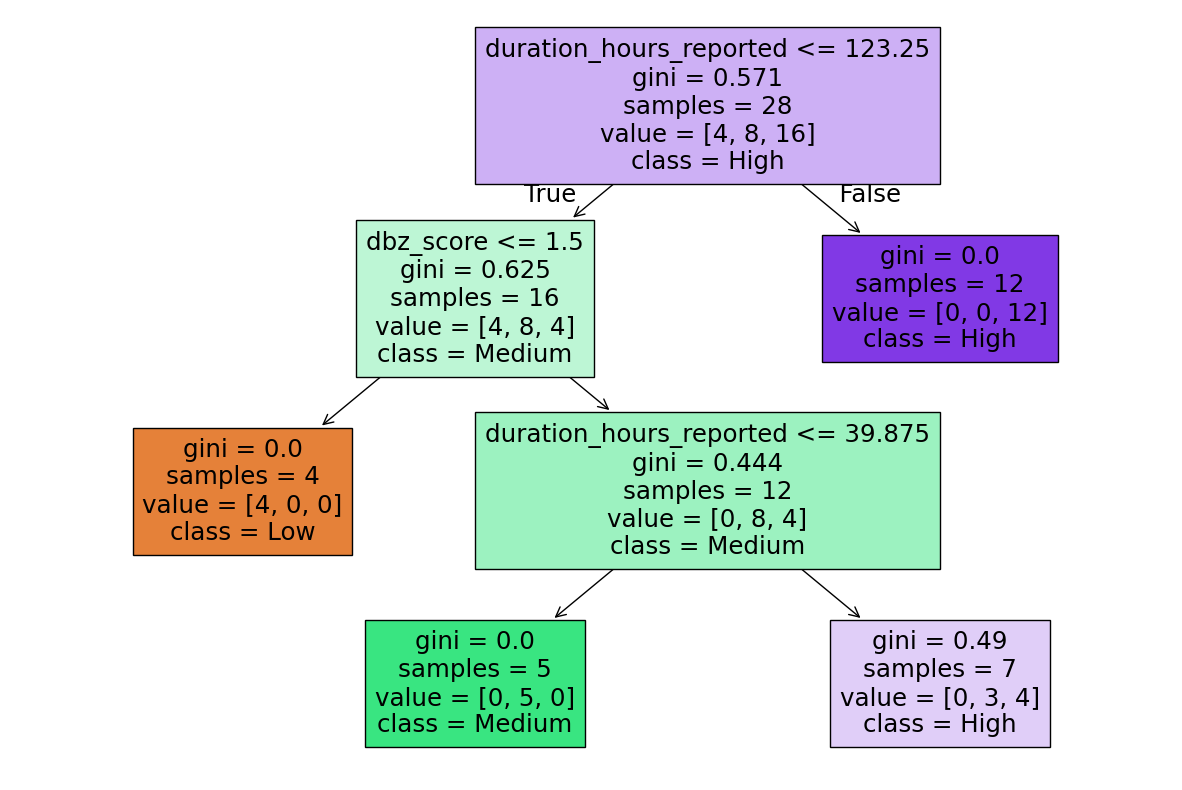

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree.fit(X, y)

plt.figure(figsize=(15,10))
plot_tree(tree, feature_names=features, class_names=["Low", "Medium", "High"], filled=True)
plt.show()

In [15]:
rf.fit(X, y)

importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance)

                   feature  importance
0  duration_hours_reported    0.255508
9         deep_cloud_score    0.154311
5                dbz_score    0.103230
3                 temp_min    0.094083
7       cloud_extent_score    0.090663
8          organized_score    0.090633
2                 temp_avg    0.086727
1             precip_total    0.057318
4           swe_efficiency    0.036569
6          cloud_top_score    0.030958


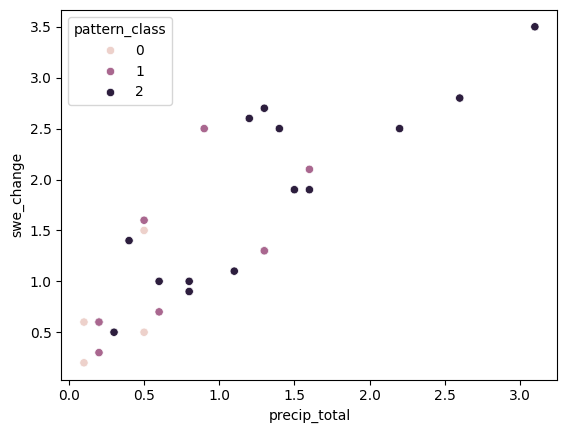

In [16]:
sns.scatterplot(x="precip_total", y="swe_change", hue="pattern_class", data=df)
plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree,
    "Random Forest": rf
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: Mean={scores.mean():.3f}, Std={scores.std():.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Logistic Regression: Mean=0.673, Std=0.153
Decision Tree: Mean=0.753, Std=0.128


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Random Forest: Mean=0.793, Std=0.194


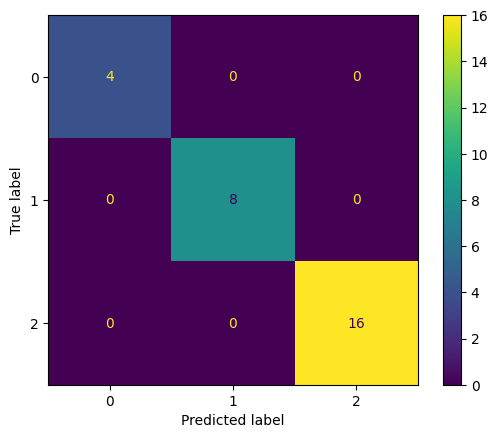

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf.fit(X, y)
y_pred = rf.predict(X)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

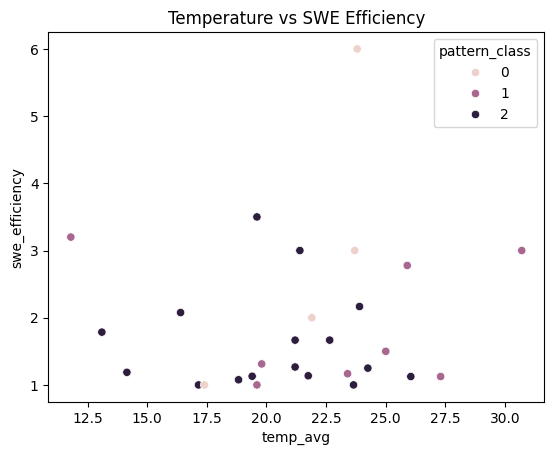

In [19]:
sns.scatterplot(x="temp_avg", y="swe_efficiency", hue="pattern_class", data=df)
plt.title("Temperature vs SWE Efficiency")
plt.show()

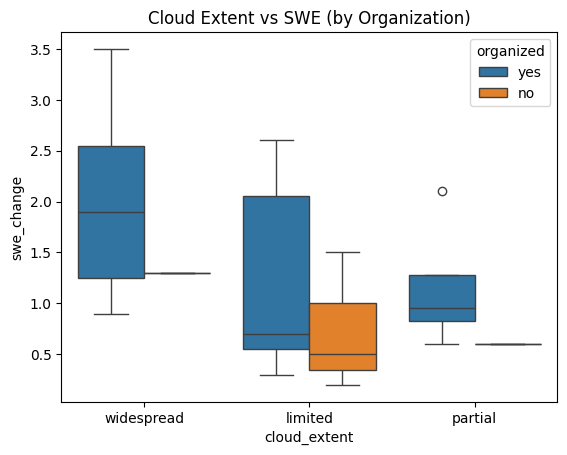

In [20]:
sns.boxplot(x="cloud_extent", y="swe_change", hue="organized", data=df)
plt.title("Cloud Extent vs SWE (by Organization)")
plt.show()

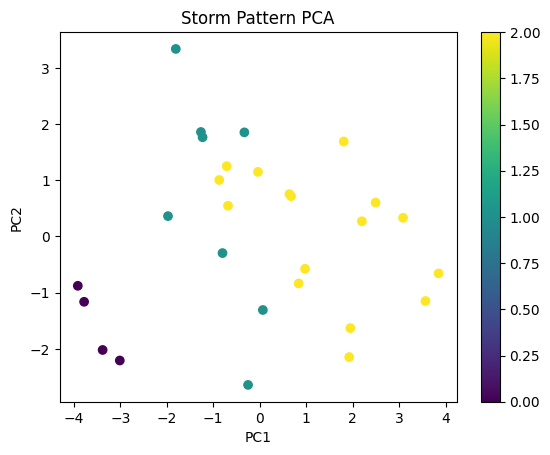

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Storm Pattern PCA")
plt.colorbar()
plt.show()

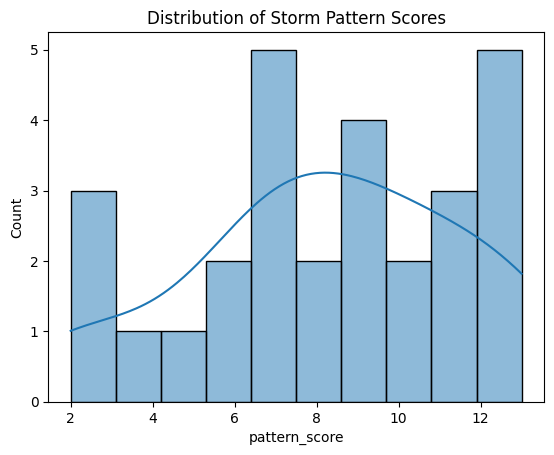

In [22]:
sns.histplot(df["pattern_score"], bins=10, kde=True)
plt.title("Distribution of Storm Pattern Scores")
plt.show()

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor()
rf_reg.fit(X, df["swe_efficiency"])

print(rf_reg.score(X, df["swe_efficiency"]))

0.9759555145108707



=== RAW DATA PREVIEW ===
  storm_event_id storm_start   storm_end  duration_hours_reported  swe_change  \
0      storm_004  2020-01-01  2020-01-02                   355.50         1.9   
1      storm_026  2021-02-15  2021-02-17                   378.00         2.8   
2      storm_038  2022-03-08  2022-03-09                   410.00         1.3   
3      storm_006  2020-01-12  2020-01-13                   127.75         2.7   
4      storm_022  2021-01-29  2021-01-30                   174.25         1.0   

   precip_total  temp_avg  temp_min freezing peak_dbz_bin intensity_category  \
0           1.5     21.20      18.3      yes        20-30           moderate   
1           2.6     18.83       7.0      yes        30-40              heavy   
2           1.3     17.15       2.3      yes        30-40              heavy   
3           1.3     16.40      12.7      yes        20-30           moderate   
4           0.8     24.25      16.0      yes        20-30           moderate   

  orga

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


Logistic Regression
  LOO Accuracy: 0.750
  LOO Balanced Accuracy: 0.688
  LOO Weighted F1: 0.729
  5-Fold Accuracy Mean: 0.633
  5-Fold Accuracy Std: 0.250

Decision Tree
  LOO Accuracy: 0.893
  LOO Balanced Accuracy: 0.833
  LOO Weighted F1: 0.895
  5-Fold Accuracy Mean: 0.827
  5-Fold Accuracy Std: 0.106

Random Forest
  LOO Accuracy: 0.857
  LOO Balanced Accuracy: 0.875
  LOO Weighted F1: 0.857
  5-Fold Accuracy Mean: 0.787
  5-Fold Accuracy Std: 0.161

=== SUCCESS CLASSIFICATION PERFORMANCE ===
LOO Accuracy: 0.750
LOO Balanced Accuracy: 0.717
LOO Precision: 0.789
LOO Recall: 0.833
LOO F1: 0.811
5-Fold Accuracy Mean: 0.827
5-Fold Accuracy Std: 0.106

=== SWE REGRESSION PERFORMANCE ===

Random Forest Regressor (LOO)
  MAE: 0.449
  RMSE: 0.579
  R²: 0.567

Gradient Boosting Regressor (LOO)
  MAE: 0.356
  RMSE: 0.483
  R²: 0.699

=== RANDOM FOREST FEATURE IMPORTANCE: PATTERN CLASSIFICATION ===
pattern_score                 0.1892
SES                           0.1037
duration_hours_re

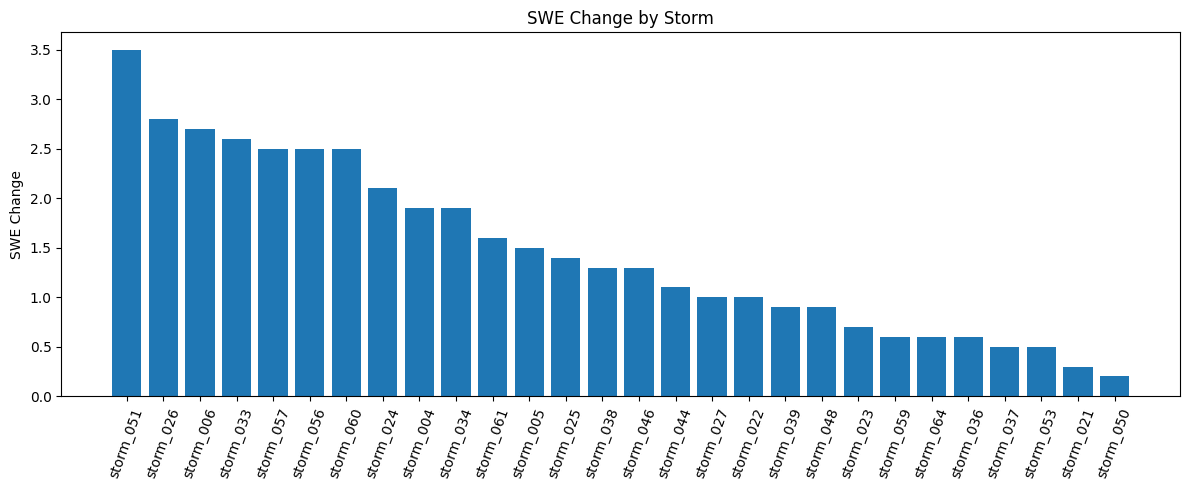

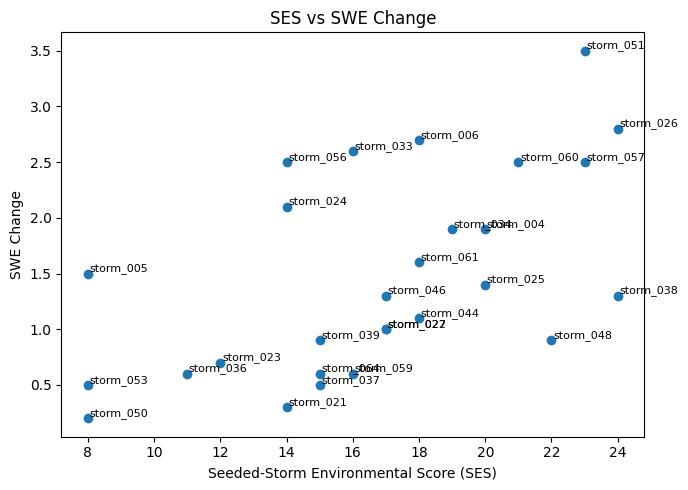

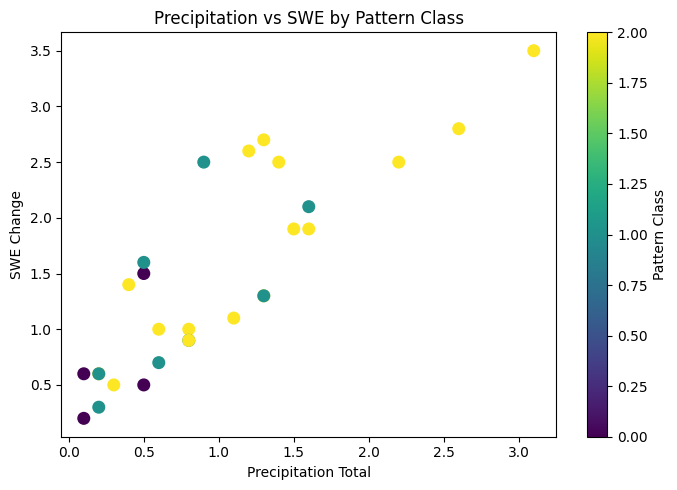

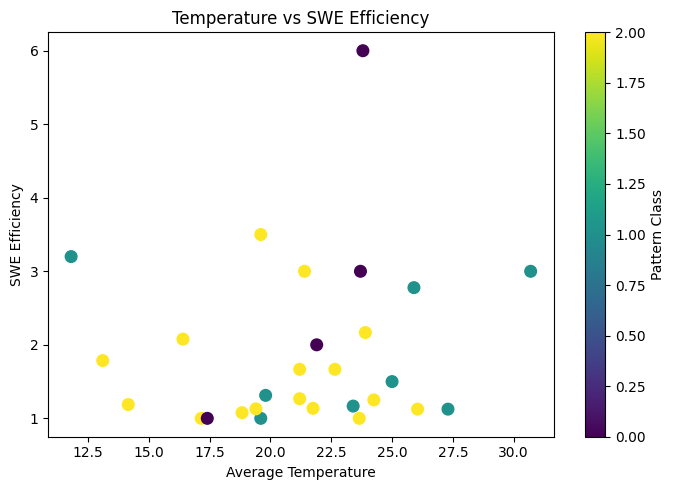

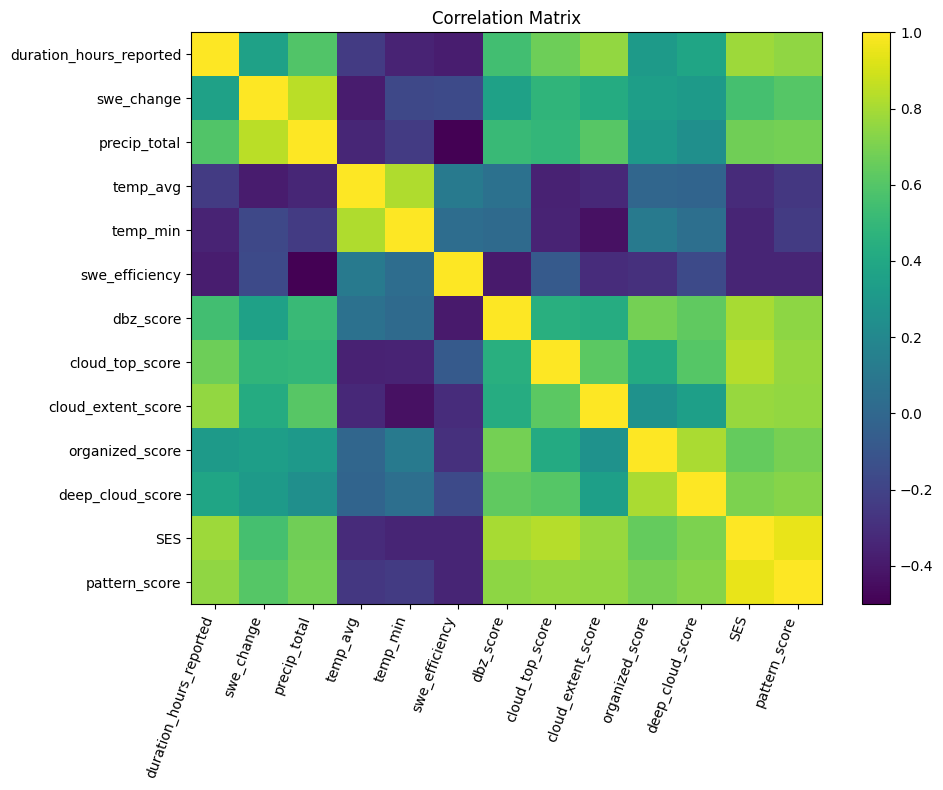

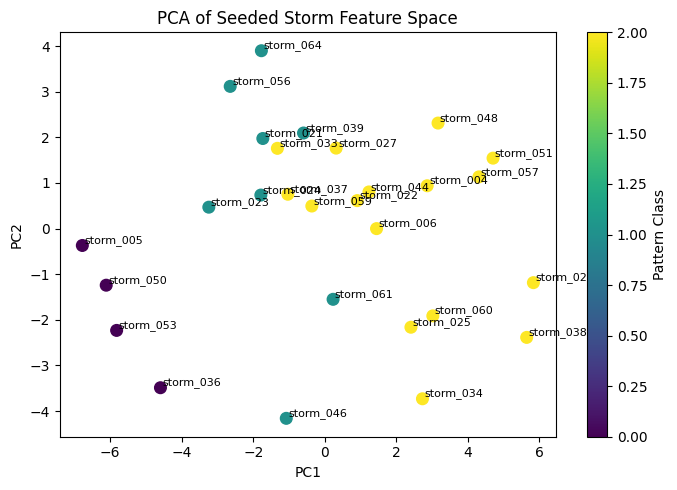

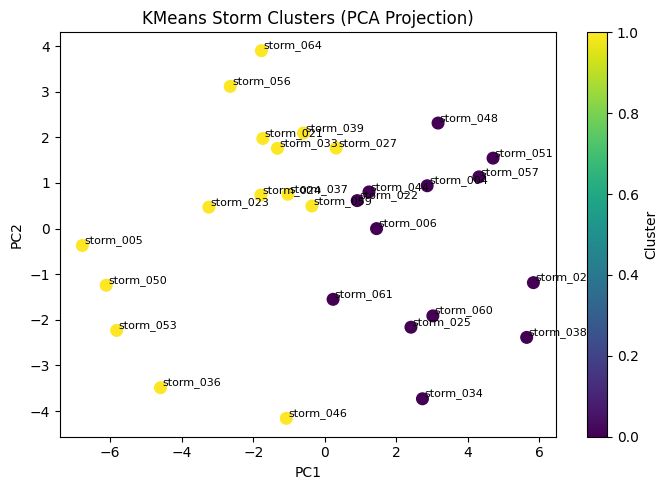

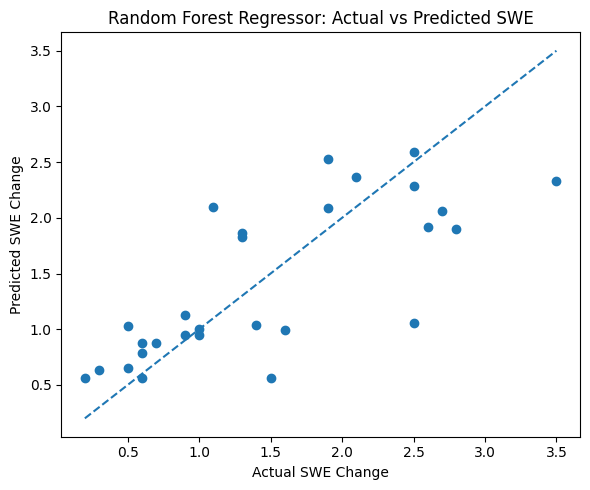

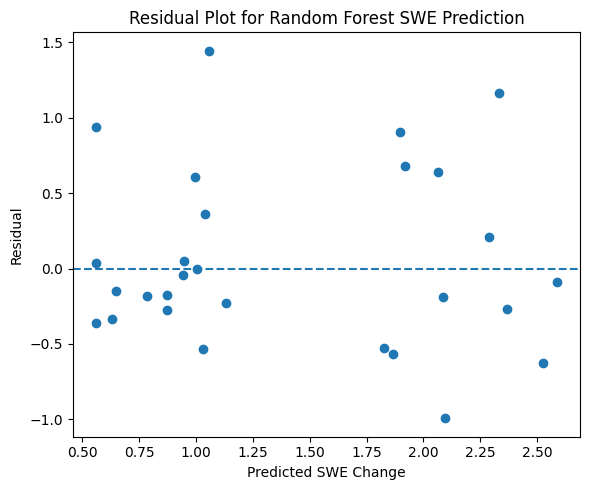

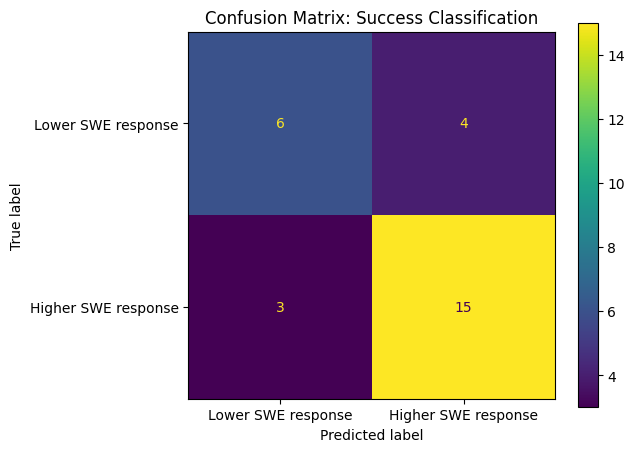

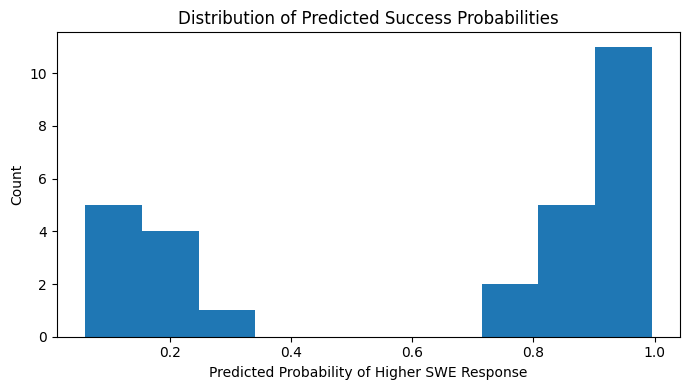

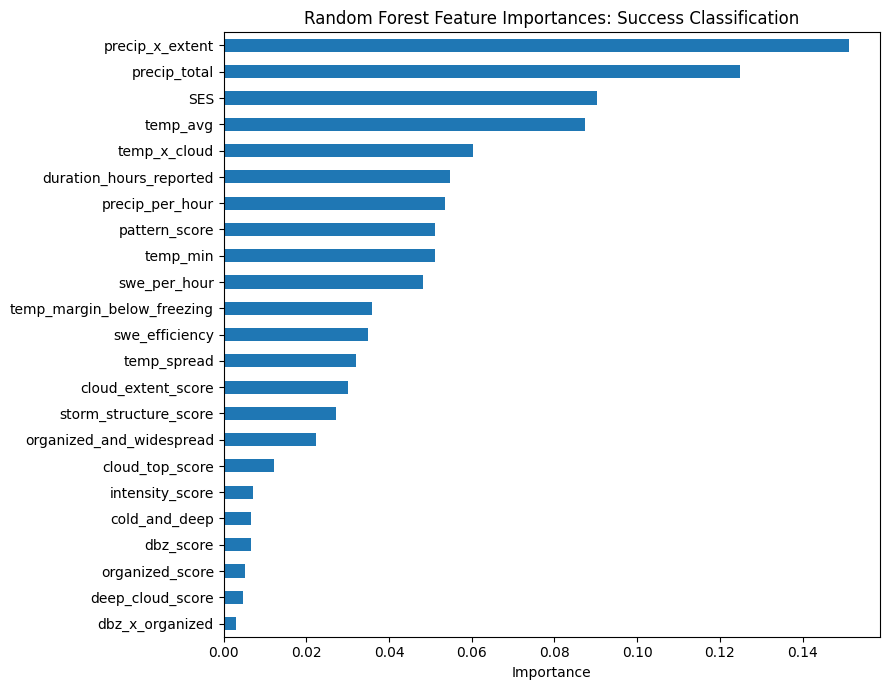

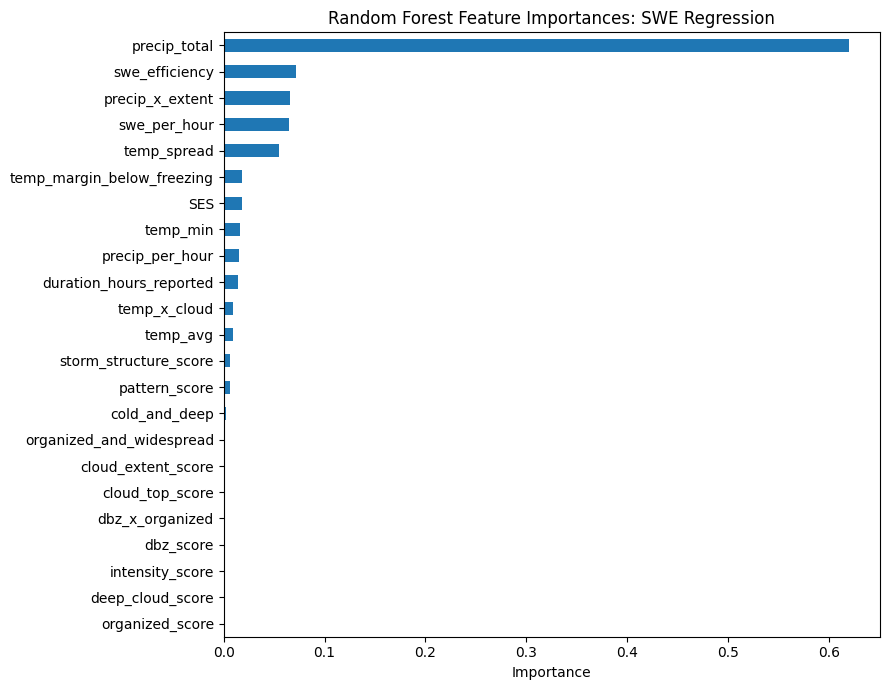

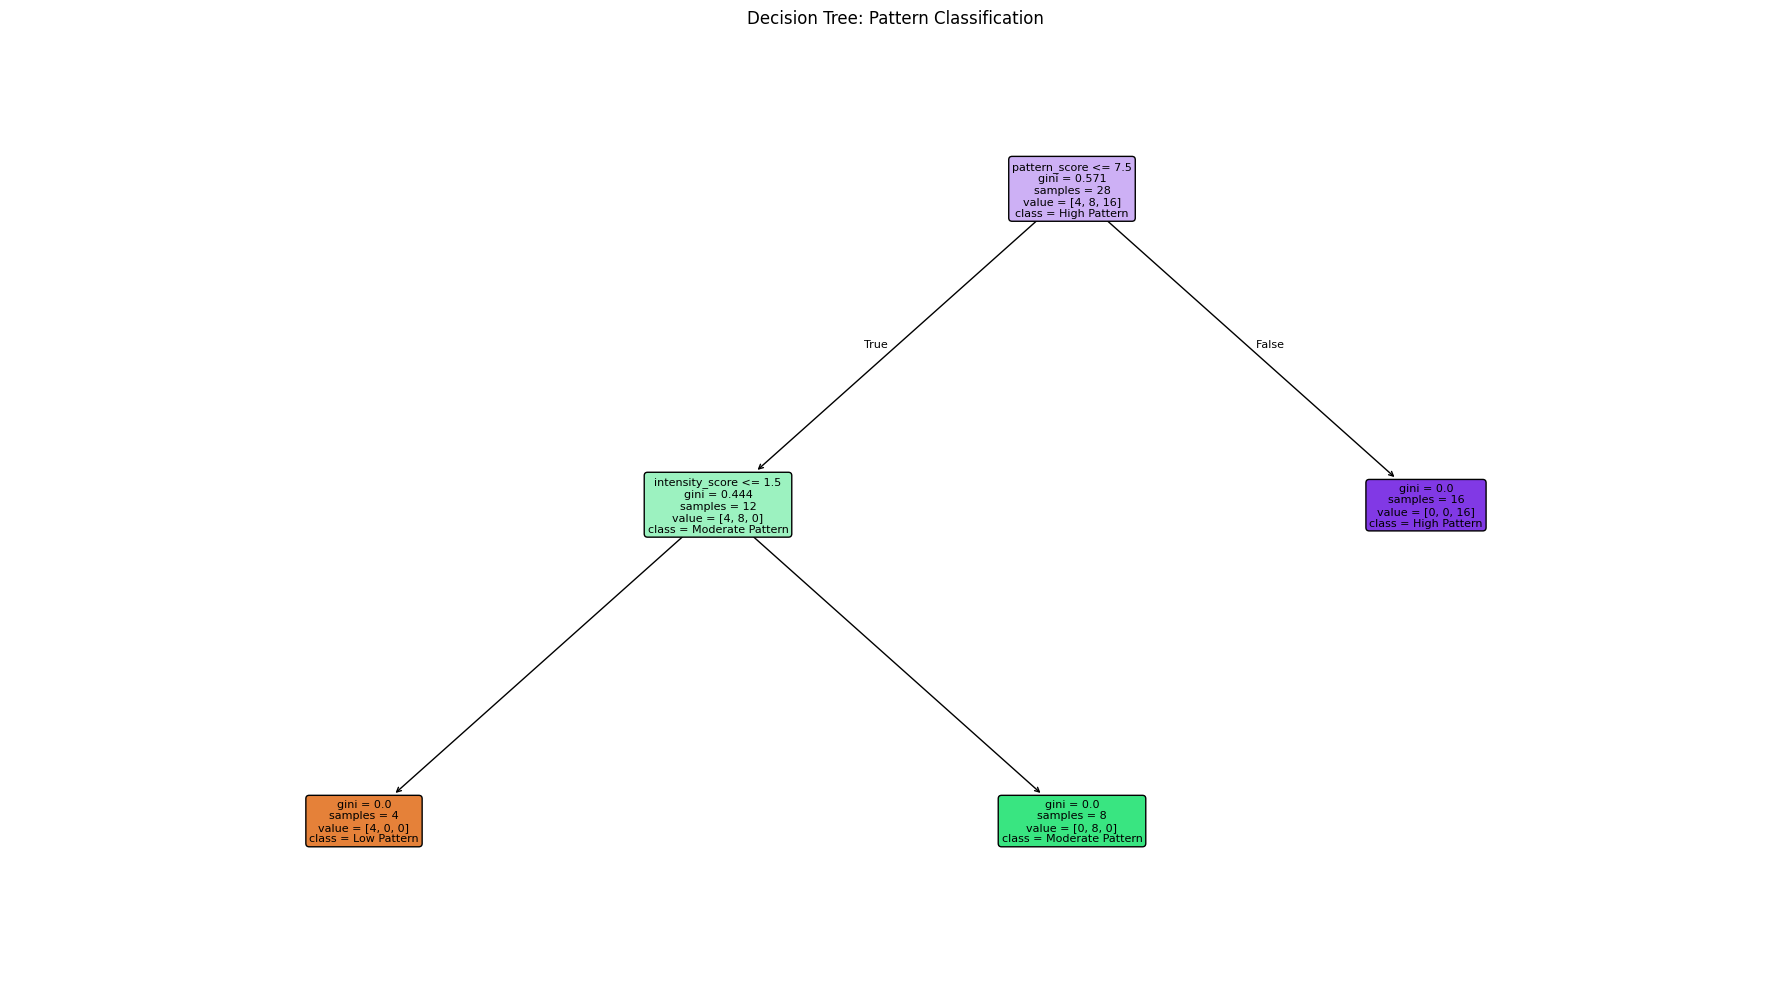


=== EXAMPLE CURRENT-STORM EVALUATION ===
{'pattern_score': 12, 'pattern_class_from_rule': 2, 'SES': 21, 'predicted_swe_change': 1.717, 'predicted_success_probability': 0.907, 'predicted_pattern_class_model': 2, 'consistency_label': 'HIGHLY CONSISTENT WITH STRONG SEEDED-STORM CONDITIONS'}

Saved enriched dataset to: phase2_enriched_output.csv


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    LeaveOneOut,
    KFold,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance


# =========================================================
# 1. LOAD DATA
# =========================================================
# Put your dataset in a file called "seeded_storms.csv"
# If it is tab-separated from Google Sheets export / paste, this still usually works.
# If needed, change the filename below.

FILE_NAME = "data - Sheet5.csv"

# Tries to auto-detect delimiter (comma or tab)
df = pd.read_csv(FILE_NAME, sep=None, engine="python")

print("\n=== RAW DATA PREVIEW ===")
print(df.head())
print("\n=== SHAPE ===")
print(df.shape)


# =========================================================
# 2. BASIC CLEANING
# =========================================================
# Standardize column names just in case
df.columns = [c.strip() for c in df.columns]

# Convert dates
df["storm_start"] = pd.to_datetime(df["storm_start"])
df["storm_end"] = pd.to_datetime(df["storm_end"])

# Ensure numeric columns are numeric
numeric_cols = [
    "duration_hours_reported",
    "swe_change",
    "precip_total",
    "temp_avg",
    "temp_min"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with key missing values
df = df.dropna(subset=numeric_cols).copy()

print("\n=== CLEANED DATA PREVIEW ===")
print(df.head())


# =========================================================
# 3. ENCODE CATEGORICAL VARIABLES
# =========================================================
dbz_map = {"10-20": 1, "20-30": 2, "30-40": 3}
cloud_top_map = {"warm": 1, "moderately_cold": 2, "very_cold": 3}
cloud_extent_map = {"limited": 1, "partial": 2, "widespread": 3}
yesno_map = {"no": 0, "yes": 1}
intensity_map = {"light": 1, "moderate": 2, "heavy": 3}

df["dbz_score"] = df["peak_dbz_bin"].map(dbz_map)
df["cloud_top_score"] = df["cloud_top_category"].map(cloud_top_map)
df["cloud_extent_score"] = df["cloud_extent"].map(cloud_extent_map)
df["organized_score"] = df["organized"].map(yesno_map)
df["deep_cloud_score"] = df["deep_cloud_present"].map(yesno_map)
df["freezing_score"] = df["freezing"].map(yesno_map)
df["intensity_score"] = df["intensity_category"].map(intensity_map)

# Check encoding success
encoded_cols = [
    "dbz_score",
    "cloud_top_score",
    "cloud_extent_score",
    "organized_score",
    "deep_cloud_score",
    "freezing_score",
    "intensity_score"
]

if df[encoded_cols].isnull().any().any():
    print("\nWARNING: Some categorical mappings produced NaN values.")
    print(df[df[encoded_cols].isnull().any(axis=1)][[
        "storm_event_id", "peak_dbz_bin", "cloud_top_category",
        "cloud_extent", "organized", "deep_cloud_present",
        "freezing", "intensity_category"
    ]])


# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================
# Add epsilon to avoid divide-by-zero
eps = 1e-6

df["swe_efficiency"] = df["swe_change"] / (df["precip_total"] + eps)
df["temp_spread"] = df["temp_avg"] - df["temp_min"]
df["temp_margin_below_freezing"] = 32 - df["temp_min"]
df["precip_per_hour"] = df["precip_total"] / (df["duration_hours_reported"] + eps)
df["swe_per_hour"] = df["swe_change"] / (df["duration_hours_reported"] + eps)

# Interaction / composite features
df["storm_structure_score"] = (
    df["cloud_top_score"] +
    df["cloud_extent_score"] +
    df["organized_score"] +
    df["deep_cloud_score"] +
    df["dbz_score"]
)

df["cold_and_deep"] = df["cloud_top_score"] * df["deep_cloud_score"]
df["organized_and_widespread"] = df["organized_score"] * df["cloud_extent_score"]
df["dbz_x_organized"] = df["dbz_score"] * df["organized_score"]
df["precip_x_extent"] = df["precip_total"] * df["cloud_extent_score"]
df["temp_x_cloud"] = df["temp_margin_below_freezing"] * df["cloud_top_score"]

# Pattern score based on seeded-storm atmospheric consistency
def compute_pattern_score(row):
    score = 0

    # Organization and deep cloud
    if row["organized_score"] == 1:
        score += 2
    if row["deep_cloud_score"] == 1:
        score += 2

    # Cloud-top conditions
    if row["cloud_top_score"] == 2:
        score += 1
    elif row["cloud_top_score"] == 3:
        score += 2

    # Cloud extent
    if row["cloud_extent_score"] == 2:
        score += 1
    elif row["cloud_extent_score"] == 3:
        score += 2

    # Radar intensity
    if row["dbz_score"] == 2:
        score += 1
    elif row["dbz_score"] == 3:
        score += 2

    # Favorable temperature window
    if 15 <= row["temp_avg"] <= 24:
        score += 2

    # Precipitation above median
    if row["precip_total"] > df["precip_total"].median():
        score += 1

    return score

df["pattern_score"] = df.apply(compute_pattern_score, axis=1)

# Pattern class target
def classify_pattern(score):
    if score <= 4:
        return 0   # low pattern
    elif score <= 7:
        return 1   # moderate pattern
    else:
        return 2   # high pattern

df["pattern_class"] = df["pattern_score"].apply(classify_pattern)

# Binary "success" target for SWE-based classification
# This does not claim causality; it just classifies stronger snow-response environments
df["success"] = (df["swe_change"] >= 1.0).astype(int)

# Seeded-storm environmental score (SES)
def seedability_environment_score(row):
    score = 0

    # Temperature contribution
    if row["temp_min"] < 10:
        score += 3
    elif row["temp_min"] < 20:
        score += 2
    elif row["temp_min"] < 32:
        score += 1

    # Cloud contribution
    score += row["cloud_top_score"] * 2

    # Cloud extent
    score += row["cloud_extent_score"]

    # Reflectivity / storm intensity
    score += row["intensity_score"] * 2
    score += row["dbz_score"]

    # Organization / deep cloud
    score += row["organized_score"]
    score += row["deep_cloud_score"]

    # Precip threshold
    if row["precip_total"] >= 1.0:
        score += 1

    return score

df["SES"] = df.apply(seedability_environment_score, axis=1)


# =========================================================
# 5. DESCRIPTIVE STATISTICS
# =========================================================
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df[[
    "duration_hours_reported",
    "swe_change",
    "precip_total",
    "temp_avg",
    "temp_min",
    "swe_efficiency",
    "pattern_score",
    "SES"
]].describe())

print("\n=== CLASS COUNTS: PATTERN_CLASS ===")
print(df["pattern_class"].value_counts().sort_index())

print("\n=== CLASS COUNTS: SUCCESS ===")
print(df["success"].value_counts().sort_index())

print("\n=== GROUPED SUMMARY: BY peak_dbz_bin ===")
print(df.groupby("peak_dbz_bin")[[
    "swe_change", "precip_total", "duration_hours_reported", "swe_efficiency"
]].mean().round(3))

print("\n=== GROUPED SUMMARY: BY cloud_top_category ===")
print(df.groupby("cloud_top_category")[[
    "swe_change", "precip_total", "duration_hours_reported", "swe_efficiency"
]].mean().round(3))

print("\n=== GROUPED SUMMARY: BY cloud_extent ===")
print(df.groupby("cloud_extent")[[
    "swe_change", "precip_total", "duration_hours_reported", "swe_efficiency"
]].mean().round(3))

print("\n=== GROUPED SUMMARY: organized vs not ===")
print(df.groupby("organized")[[
    "swe_change", "precip_total", "duration_hours_reported", "swe_efficiency"
]].mean().round(3))


# =========================================================
# 6. CORRELATION ANALYSIS
# =========================================================
corr_cols = [
    "duration_hours_reported",
    "swe_change",
    "precip_total",
    "temp_avg",
    "temp_min",
    "swe_efficiency",
    "dbz_score",
    "cloud_top_score",
    "cloud_extent_score",
    "organized_score",
    "deep_cloud_score",
    "SES",
    "pattern_score"
]

corr = df[corr_cols].corr()

print("\n=== CORRELATION MATRIX ===")
print(corr.round(3))


# =========================================================
# 7. FEATURE SETS
# =========================================================
feature_cols = [
    "duration_hours_reported",
    "precip_total",
    "temp_avg",
    "temp_min",
    "swe_efficiency",
    "temp_spread",
    "temp_margin_below_freezing",
    "precip_per_hour",
    "swe_per_hour",
    "dbz_score",
    "cloud_top_score",
    "cloud_extent_score",
    "organized_score",
    "deep_cloud_score",
    "intensity_score",
    "storm_structure_score",
    "cold_and_deep",
    "organized_and_widespread",
    "dbz_x_organized",
    "precip_x_extent",
    "temp_x_cloud",
    "SES",
    "pattern_score"
]

X = df[feature_cols].copy()
y_pattern = df["pattern_class"].copy()
y_success = df["success"].copy()
y_reg = df["swe_change"].copy()


# =========================================================
# 8. PCA
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2", "PC3"]
)

print("\n=== PCA EXPLAINED VARIANCE RATIO ===")
print(np.round(pca.explained_variance_ratio_, 4))

print("\n=== PCA LOADINGS (sorted by PC1 absolute value) ===")
print(pca_loadings.reindex(
    pca_loadings["PC1"].abs().sort_values(ascending=False).index
).round(3))


# =========================================================
# 9. CLUSTERING
# =========================================================
print("\n=== SILHOUETTE SCORES FOR KMEANS ===")
best_k = None
best_score = -1

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: silhouette={score:.3f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nBest k based on silhouette score: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("\n=== CLUSTER SUMMARY ===")
print(df.groupby("cluster")[[
    "swe_change",
    "precip_total",
    "duration_hours_reported",
    "temp_avg",
    "dbz_score",
    "cloud_top_score",
    "cloud_extent_score",
    "organized_score",
    "deep_cloud_score",
    "SES"
]].mean().round(3))


# =========================================================
# 10. MODELS
# =========================================================
# Pattern classification
log_model = LogisticRegression(max_iter=3000, multi_class="auto")
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
rf_pattern = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=1,
    random_state=42
)

# Success classification
rf_success = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=1,
    random_state=42
)

# Regression
rf_reg = RandomForestRegressor(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=1,
    random_state=42
)

gb_reg = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)


# =========================================================
# 11. VALIDATION SETUPS
# =========================================================
loo = LeaveOneOut()
kfold_5 = KFold(n_splits=5, shuffle=True, random_state=42)
strat_kfold_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# =========================================================
# 12. PATTERN CLASSIFICATION: LOO + 5-FOLD
# =========================================================
print("\n=== PATTERN CLASSIFICATION PERFORMANCE ===")

pattern_models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_pattern
}

for name, model in pattern_models.items():
    # LOO predictions
    y_pred_loo = cross_val_predict(model, X, y_pattern, cv=loo)

    acc = accuracy_score(y_pattern, y_pred_loo)
    bal_acc = balanced_accuracy_score(y_pattern, y_pred_loo)
    f1 = f1_score(y_pattern, y_pred_loo, average="weighted")

    # 5-fold score
    scores_5 = cross_val_score(model, X, y_pattern, cv=kfold_5, scoring="accuracy")

    print(f"\n{name}")
    print(f"  LOO Accuracy: {acc:.3f}")
    print(f"  LOO Balanced Accuracy: {bal_acc:.3f}")
    print(f"  LOO Weighted F1: {f1:.3f}")
    print(f"  5-Fold Accuracy Mean: {scores_5.mean():.3f}")
    print(f"  5-Fold Accuracy Std: {scores_5.std():.3f}")


# =========================================================
# 13. SUCCESS CLASSIFICATION: LOO + 5-FOLD
# =========================================================
print("\n=== SUCCESS CLASSIFICATION PERFORMANCE ===")

y_success_pred_loo = cross_val_predict(rf_success, X, y_success, cv=loo)

print(f"LOO Accuracy: {accuracy_score(y_success, y_success_pred_loo):.3f}")
print(f"LOO Balanced Accuracy: {balanced_accuracy_score(y_success, y_success_pred_loo):.3f}")
print(f"LOO Precision: {precision_score(y_success, y_success_pred_loo, zero_division=0):.3f}")
print(f"LOO Recall: {recall_score(y_success, y_success_pred_loo, zero_division=0):.3f}")
print(f"LOO F1: {f1_score(y_success, y_success_pred_loo, zero_division=0):.3f}")

success_scores_5 = cross_val_score(rf_success, X, y_success, cv=strat_kfold_5, scoring="accuracy")
print(f"5-Fold Accuracy Mean: {success_scores_5.mean():.3f}")
print(f"5-Fold Accuracy Std: {success_scores_5.std():.3f}")


# =========================================================
# 14. REGRESSION: LOO + 5-FOLD
# =========================================================
print("\n=== SWE REGRESSION PERFORMANCE ===")

rf_reg_pred_loo = cross_val_predict(rf_reg, X, y_reg, cv=loo)
gb_reg_pred_loo = cross_val_predict(gb_reg, X, y_reg, cv=loo)

def print_regression_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  MAE: {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²: {r2:.3f}")

print_regression_metrics("Random Forest Regressor (LOO)", y_reg, rf_reg_pred_loo)
print_regression_metrics("Gradient Boosting Regressor (LOO)", y_reg, gb_reg_pred_loo)


# =========================================================
# 15. FIT FINAL MODELS ON FULL DATA
# =========================================================
rf_pattern.fit(X, y_pattern)
rf_success.fit(X, y_success)
rf_reg.fit(X, y_reg)
gb_reg.fit(X, y_reg)
tree_model.fit(X, y_pattern)


# =========================================================
# 16. FEATURE IMPORTANCE
# =========================================================
print("\n=== RANDOM FOREST FEATURE IMPORTANCE: PATTERN CLASSIFICATION ===")
rf_pattern_imp = pd.Series(rf_pattern.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_pattern_imp.round(4))

print("\n=== RANDOM FOREST FEATURE IMPORTANCE: SUCCESS CLASSIFICATION ===")
rf_success_imp = pd.Series(rf_success.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_success_imp.round(4))

print("\n=== RANDOM FOREST FEATURE IMPORTANCE: SWE REGRESSION ===")
rf_reg_imp = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_reg_imp.round(4))


# =========================================================
# 17. PERMUTATION IMPORTANCE
# =========================================================
print("\n=== PERMUTATION IMPORTANCE: SUCCESS CLASSIFICATION ===")
perm_success = permutation_importance(rf_success, X, y_success, n_repeats=30, random_state=42)
perm_success_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_success.importances_mean,
    "importance_std": perm_success.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_success_df.round(4))

print("\n=== PERMUTATION IMPORTANCE: SWE REGRESSION ===")
perm_reg = permutation_importance(rf_reg, X, y_reg, n_repeats=30, random_state=42)
perm_reg_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_reg.importances_mean,
    "importance_std": perm_reg.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_reg_df.round(4))


# =========================================================
# 18. ABLATION STUDY
# =========================================================
print("\n=== ABLATION STUDY: SUCCESS CLASSIFICATION ===")

feature_groups = {
    "temperature_only": ["temp_avg", "temp_min", "temp_spread", "temp_margin_below_freezing"],
    "precip_radar_only": ["precip_total", "precip_per_hour", "dbz_score", "intensity_score"],
    "cloud_only": ["cloud_top_score", "cloud_extent_score", "organized_score", "deep_cloud_score"],
    "engineered_only": [
        "storm_structure_score", "cold_and_deep", "organized_and_widespread",
        "dbz_x_organized", "precip_x_extent", "temp_x_cloud", "SES", "pattern_score"
    ],
    "all_features": feature_cols
}

for group_name, cols in feature_groups.items():
    X_sub = df[cols]
    pred = cross_val_predict(
        RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42),
        X_sub,
        y_success,
        cv=loo
    )
    acc = accuracy_score(y_success, pred)
    bal_acc = balanced_accuracy_score(y_success, pred)
    print(f"{group_name}: Accuracy={acc:.3f}, Balanced Accuracy={bal_acc:.3f}")


# =========================================================
# 19. VISUALIZATIONS
# =========================================================

# A. SWE Change by storm
plt.figure(figsize=(12, 5))
plot_df = df.sort_values("swe_change", ascending=False)
plt.bar(plot_df["storm_event_id"], plot_df["swe_change"])
plt.xticks(rotation=70)
plt.ylabel("SWE Change")
plt.title("SWE Change by Storm")
plt.tight_layout()
plt.show()

# B. SES vs SWE
plt.figure(figsize=(7, 5))
plt.scatter(df["SES"], df["swe_change"])
for _, row in df.iterrows():
    plt.text(row["SES"] + 0.05, row["swe_change"] + 0.02, row["storm_event_id"], fontsize=8)
plt.xlabel("Seeded-Storm Environmental Score (SES)")
plt.ylabel("SWE Change")
plt.title("SES vs SWE Change")
plt.tight_layout()
plt.show()

# C. Precip vs SWE colored by pattern class
plt.figure(figsize=(7, 5))
scatter = plt.scatter(df["precip_total"], df["swe_change"], c=df["pattern_class"], s=70)
plt.xlabel("Precipitation Total")
plt.ylabel("SWE Change")
plt.title("Precipitation vs SWE by Pattern Class")
plt.colorbar(scatter, label="Pattern Class")
plt.tight_layout()
plt.show()

# D. Temp vs SWE efficiency
plt.figure(figsize=(7, 5))
scatter = plt.scatter(df["temp_avg"], df["swe_efficiency"], c=df["pattern_class"], s=70)
plt.xlabel("Average Temperature")
plt.ylabel("SWE Efficiency")
plt.title("Temperature vs SWE Efficiency")
plt.colorbar(scatter, label="Pattern Class")
plt.tight_layout()
plt.show()

# E. Correlation matrix
plt.figure(figsize=(10, 8))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# F. PCA plot
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["pattern_class"], s=70)
for i, storm in enumerate(df["storm_event_id"]):
    plt.text(X_pca[i, 0] + 0.05, X_pca[i, 1] + 0.05, storm, fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Seeded Storm Feature Space")
plt.colorbar(scatter, label="Pattern Class")
plt.tight_layout()
plt.show()

# G. Cluster plot
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], s=70)
for i, storm in enumerate(df["storm_event_id"]):
    plt.text(X_pca[i, 0] + 0.05, X_pca[i, 1] + 0.05, storm, fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Storm Clusters (PCA Projection)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

# H. Random Forest actual vs predicted SWE
plt.figure(figsize=(6, 5))
plt.scatter(y_reg, rf_reg_pred_loo)
min_v = min(y_reg.min(), rf_reg_pred_loo.min())
max_v = max(y_reg.max(), rf_reg_pred_loo.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Actual SWE Change")
plt.ylabel("Predicted SWE Change")
plt.title("Random Forest Regressor: Actual vs Predicted SWE")
plt.tight_layout()
plt.show()

# I. Residual plot
rf_residuals = y_reg - rf_reg_pred_loo
plt.figure(figsize=(6, 5))
plt.scatter(rf_reg_pred_loo, rf_residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted SWE Change")
plt.ylabel("Residual")
plt.title("Residual Plot for Random Forest SWE Prediction")
plt.tight_layout()
plt.show()

# J. Confusion matrix for success classification
cm = confusion_matrix(y_success, y_success_pred_loo)
disp = ConfusionMatrixDisplay(cm, display_labels=["Lower SWE response", "Higher SWE response"])
disp.plot()
plt.title("Confusion Matrix: Success Classification")
plt.tight_layout()
plt.show()

# K. Predicted probabilities for success classification
rf_success_probs = rf_success.predict_proba(X)[:, 1]
plt.figure(figsize=(7, 4))
plt.hist(rf_success_probs, bins=10)
plt.xlabel("Predicted Probability of Higher SWE Response")
plt.ylabel("Count")
plt.title("Distribution of Predicted Success Probabilities")
plt.tight_layout()
plt.show()

# L. Feature importance plot: success classifier
plt.figure(figsize=(9, 7))
rf_success_imp.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances: Success Classification")
plt.tight_layout()
plt.show()

# M. Feature importance plot: SWE regressor
plt.figure(figsize=(9, 7))
rf_reg_imp.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances: SWE Regression")
plt.tight_layout()
plt.show()

# N. Decision tree visualization for pattern classification
plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=["Low Pattern", "Moderate Pattern", "High Pattern"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree: Pattern Classification")
plt.tight_layout()
plt.show()


# =========================================================
# 20. CURRENT-STORM EVALUATION FUNCTION
# =========================================================
def evaluate_current_storm(
    duration_hours_reported,
    precip_total,
    temp_avg,
    temp_min,
    freezing,
    peak_dbz_bin,
    intensity_category,
    organized,
    cloud_top_category,
    cloud_extent,
    deep_cloud_present
):
    # Encode
    dbz_score = dbz_map[peak_dbz_bin]
    cloud_top_score = cloud_top_map[cloud_top_category]
    cloud_extent_score = cloud_extent_map[cloud_extent]
    organized_score = yesno_map[organized]
    deep_cloud_score = yesno_map[deep_cloud_present]
    freezing_score = yesno_map[freezing]
    intensity_score = intensity_map[intensity_category]

    # Derived features
    swe_efficiency_placeholder = 0.0  # unknown in current-time assessment
    temp_spread_placeholder = temp_avg - temp_min
    temp_margin_below_freezing = 32 - temp_min
    precip_per_hour = precip_total / (duration_hours_reported + eps)
    swe_per_hour_placeholder = 0.0

    storm_structure_score = (
        cloud_top_score +
        cloud_extent_score +
        organized_score +
        deep_cloud_score +
        dbz_score
    )

    cold_and_deep = cloud_top_score * deep_cloud_score
    organized_and_widespread = organized_score * cloud_extent_score
    dbz_x_organized = dbz_score * organized_score
    precip_x_extent = precip_total * cloud_extent_score
    temp_x_cloud = temp_margin_below_freezing * cloud_top_score

    # Pattern score
    score = 0
    if organized_score == 1:
        score += 2
    if deep_cloud_score == 1:
        score += 2
    if cloud_top_score == 2:
        score += 1
    elif cloud_top_score == 3:
        score += 2
    if cloud_extent_score == 2:
        score += 1
    elif cloud_extent_score == 3:
        score += 2
    if dbz_score == 2:
        score += 1
    elif dbz_score == 3:
        score += 2
    if 15 <= temp_avg <= 24:
        score += 2
    if precip_total > df["precip_total"].median():
        score += 1

    # Pattern class
    if score <= 4:
        pattern_class = 0
    elif score <= 7:
        pattern_class = 1
    else:
        pattern_class = 2

    # SES
    ses = 0
    if temp_min < 10:
        ses += 3
    elif temp_min < 20:
        ses += 2
    elif temp_min < 32:
        ses += 1

    ses += cloud_top_score * 2
    ses += cloud_extent_score
    ses += intensity_score * 2
    ses += dbz_score
    ses += organized_score
    ses += deep_cloud_score
    if precip_total >= 1.0:
        ses += 1

    # Build feature row
    row = pd.DataFrame([{
        "duration_hours_reported": duration_hours_reported,
        "precip_total": precip_total,
        "temp_avg": temp_avg,
        "temp_min": temp_min,
        "swe_efficiency": swe_efficiency_placeholder,
        "temp_spread": temp_spread_placeholder,
        "temp_margin_below_freezing": temp_margin_below_freezing,
        "precip_per_hour": precip_per_hour,
        "swe_per_hour": swe_per_hour_placeholder,
        "dbz_score": dbz_score,
        "cloud_top_score": cloud_top_score,
        "cloud_extent_score": cloud_extent_score,
        "organized_score": organized_score,
        "deep_cloud_score": deep_cloud_score,
        "intensity_score": intensity_score,
        "storm_structure_score": storm_structure_score,
        "cold_and_deep": cold_and_deep,
        "organized_and_widespread": organized_and_widespread,
        "dbz_x_organized": dbz_x_organized,
        "precip_x_extent": precip_x_extent,
        "temp_x_cloud": temp_x_cloud,
        "SES": ses,
        "pattern_score": score
    }])

    # Predictions
    predicted_swe_change = rf_reg.predict(row)[0]
    success_probability = rf_success.predict_proba(row)[0][1]
    predicted_pattern_class = rf_pattern.predict(row)[0]

    # Decision wording kept aligned with your plan
    if success_probability >= 0.70:
        consistency_label = "HIGHLY CONSISTENT WITH STRONG SEEDED-STORM CONDITIONS"
    elif success_probability >= 0.40:
        consistency_label = "MODERATELY CONSISTENT WITH SEEDED-STORM CONDITIONS"
    else:
        consistency_label = "WEAKLY CONSISTENT WITH STRONG SEEDED-STORM CONDITIONS"

    return {
        "pattern_score": score,
        "pattern_class_from_rule": pattern_class,
        "SES": ses,
        "predicted_swe_change": round(float(predicted_swe_change), 3),
        "predicted_success_probability": round(float(success_probability), 3),
        "predicted_pattern_class_model": int(predicted_pattern_class),
        "consistency_label": consistency_label
    }


# Example run
print("\n=== EXAMPLE CURRENT-STORM EVALUATION ===")
example = evaluate_current_storm(
    duration_hours_reported=24,
    precip_total=1.2,
    temp_avg=18.0,
    temp_min=9.0,
    freezing="yes",
    peak_dbz_bin="20-30",
    intensity_category="moderate",
    organized="yes",
    cloud_top_category="very_cold",
    cloud_extent="widespread",
    deep_cloud_present="yes"
)
print(example)


# =========================================================
# 21. EXPORT ENRICHED DATA
# =========================================================
df.to_csv("phase2_enriched_output.csv", index=False)
print("\nSaved enriched dataset to: phase2_enriched_output.csv")